In [1]:
import pandas as pd
from V2.powerball_ticket_generator import TemperatureLotteryGenerator
from V2.powerball_backtester import PowerballBacktester

In [2]:
generator = TemperatureLotteryGenerator(csv_path="V2/powerball.csv")
tix = generator.generate_ticket_batch(
    n=5,
    max_T=200,
    include_metadata=False
)

tix = pd.DataFrame(tix)
tix

,white_1,white_2,white_3,white_4,white_5,red_ball
0,9,27,46,48,59,25
1,1,3,9,48,52,17
2,10,26,52,56,57,1
3,8,22,57,62,64,7
4,11,23,44,52,56,20



### 1) Baseline single-run backtest (fixed spend, multiplier on, temperatures stored)

In [3]:
from V2.powerball_ticket_generator import TemperatureLotteryGenerator
from V2.powerball_backtester import PowerballBacktester

gen = TemperatureLotteryGenerator(csv_path="V2/powerball.csv")

bt = PowerballBacktester(
    draw_csv="V2/powerball.csv",
    jackpot_csv="V2/jackpots.csv",
    generator=gen,
    ticket_budget=100,
    use_multiplier=True,
    reinvest_percent=0.0,
    store_temperatures=True,
    rolling_window=100,
    prefer_numba=True,
    withdrawal_apy=0.0,
)

out = bt.run(seed=123456)

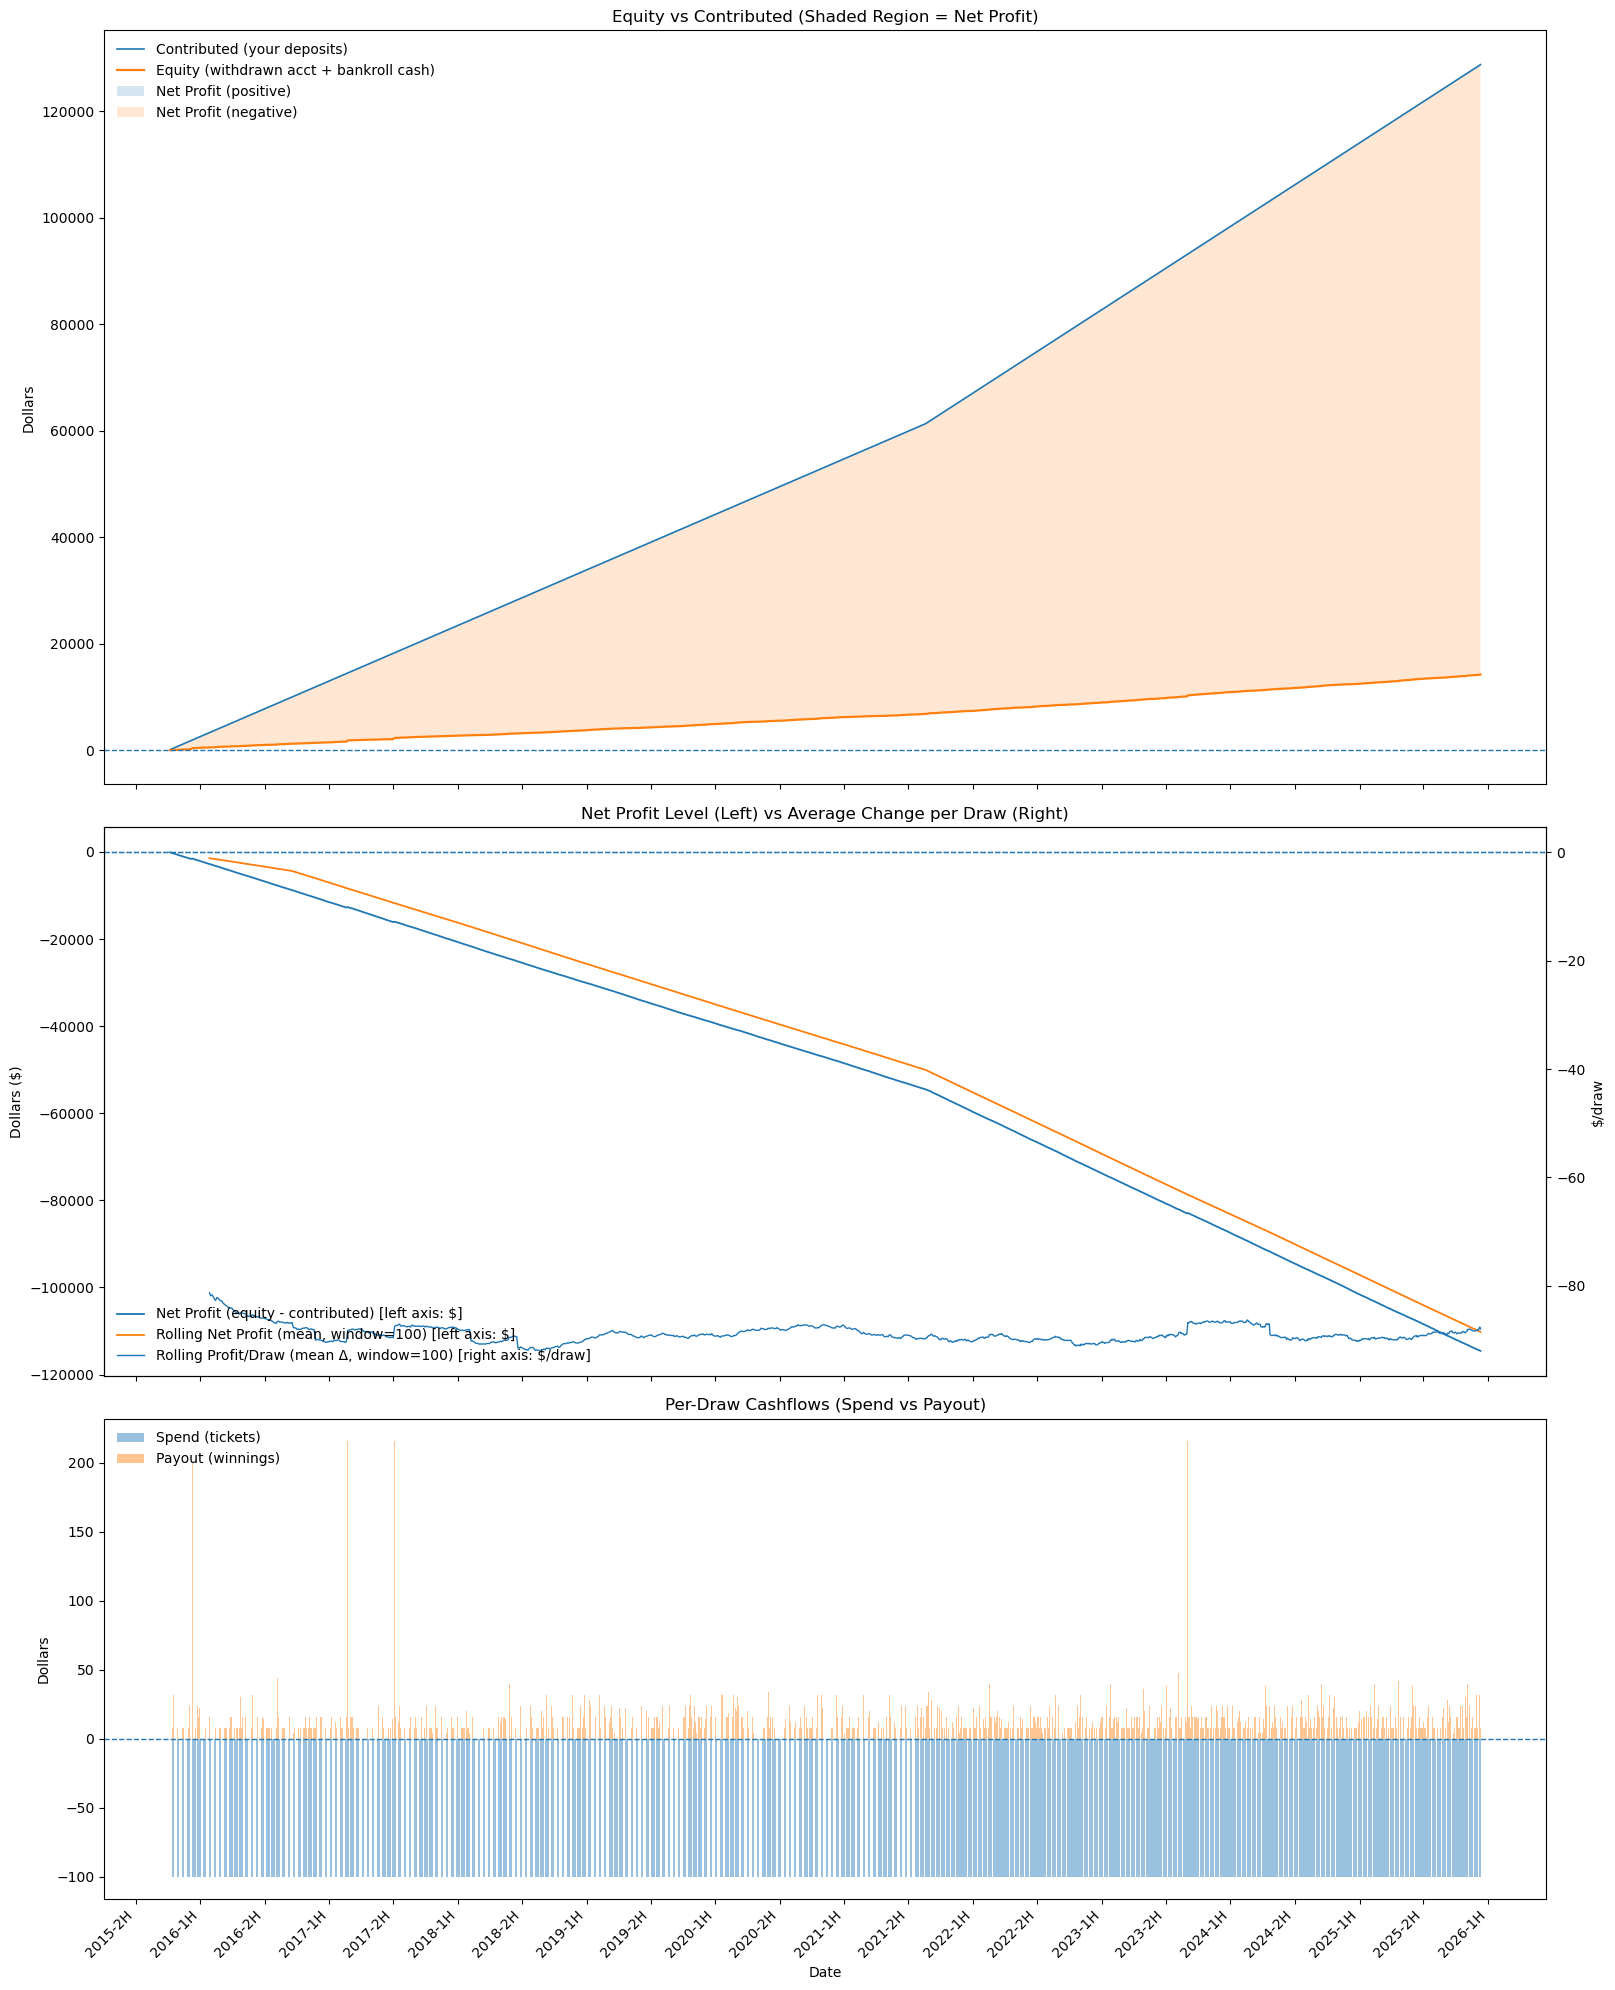

In [4]:
bt.plot_winnings(out)

In [5]:
bt.pnl_table 

,date,equity,net_profit,contributed,available,spend,draw_payout,withdrawn,withdrawn_balance,bankroll_cash
0,10/07/2015,8.0,-92.0,100.0,100.0,100.0,8.0,8.0,8.0,0.0
1,10/10/2015,16.0,-184.0,200.0,100.0,100.0,8.0,8.0,16.0,0.0
2,10/14/2015,24.0,-276.0,300.0,100.0,100.0,8.0,8.0,24.0,0.0
3,10/17/2015,56.0,-344.0,400.0,100.0,100.0,32.0,32.0,56.0,0.0
4,10/21/2015,56.0,-444.0,500.0,100.0,100.0,0.0,0.0,56.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1283,12/01/2025,14138.0,-114262.0,128400.0,100.0,100.0,8.0,8.0,14138.0,0.0
1284,12/03/2025,14146.0,-114354.0,128500.0,100.0,100.0,8.0,8.0,14146.0,0.0
1285,12/06/2025,14184.0,-114416.0,128600.0,100.0,100.0,38.0,38.0,14184.0,0.0
1286,12/08/2025,14216.0,-114484.0,128700.0,100.0,100.0,32.0,32.0,14216.0,0.0


### 2) Determinism/regression test harness (repeatability + RNG isolation)

In [6]:
out1 = bt.run(seed=123456)
ticket1 = bt.last_ticket_detail.copy()

out2 = bt.run(seed=123456)
ticket2 = bt.last_ticket_detail.copy()

assert out1.equals(out2)
assert ticket1.equals(ticket2)
assert out1["net_profit"].iat[-1] == out2["net_profit"].iat[-1]  # scalar compare

### 3) Compare reinvestment policies (fixed_exposure vs nested_compounding)

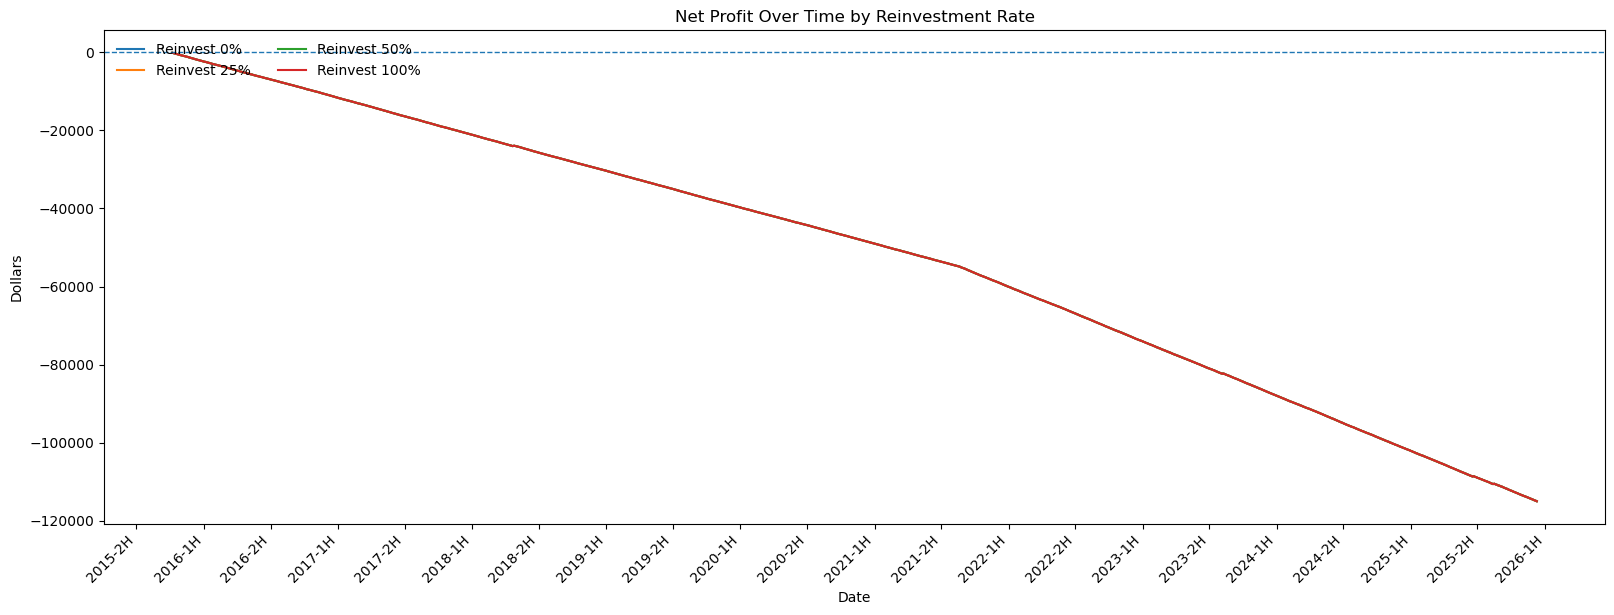

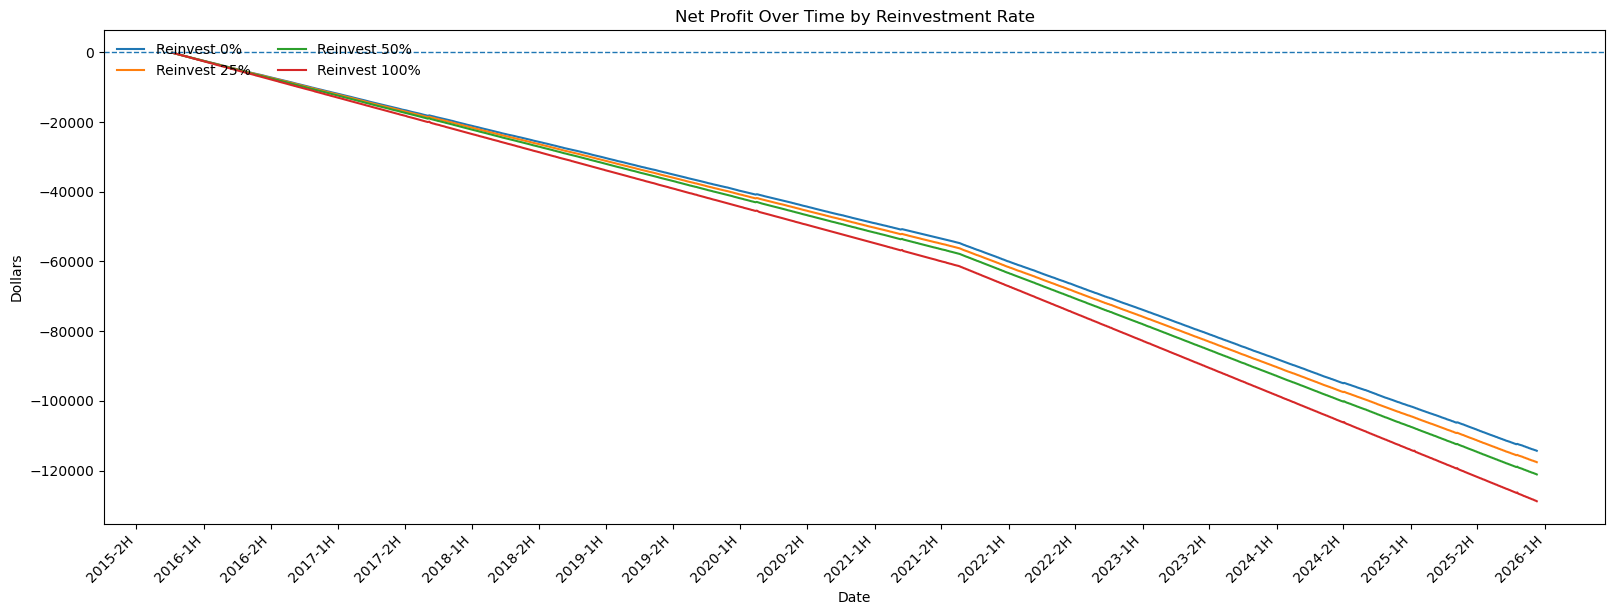

available  spend  draw_payout  draw_net  reinvested  \
reinvest_rate date                                                              
0.0           2015-10-07      100.0  100.0          0.0    -100.0         0.0   
              2015-10-10      100.0  100.0         16.0     -84.0         0.0   
              2015-10-14      100.0  100.0          0.0    -100.0         0.0   
              2015-10-17      100.0  100.0          0.0    -100.0         0.0   
              2015-10-21      100.0  100.0          4.0     -96.0         0.0   

                          withdrawn  withdrawn_balance  bankroll_cash  equity  \
reinvest_rate date                                                              
0.0           2015-10-07        0.0                0.0            0.0     0.0   
              2015-10-10       16.0               16.0            0.0    16.0   
              2015-10-14        0.0               16.0            0.0    16.0   
              2015-10-17        0.0               16.0            0.0    16.0   
              2015-10-21        4.0               20.0            0.0    20.0   

                          contributed  net_profit  rolling_pnl  \
reinvest_rate date                                               
0.0           2015-10-07        100.0      -100.0          NaN   
              2015-10-10        200.0      -184.0          NaN   
              2015-10-14        300.0      -284.0          NaN   
              2015-10-17        400.0      -384.0          NaN   
              2015-10-21        500.0      -480.0          NaN   

                          rolling_volatility  rolling_sharpe       roi  \
reinvest_rate date                                                       
0.0           2015-10-07                 NaN             NaN  0.112368   
              2015-10-10                 NaN             NaN  0.112368   
              2015-10-14                 NaN             NaN  0.112368   
              2015-10-17                 NaN             NaN  0.112368   
              2015-10-21                 NaN             NaN  0.112368   

                          net_profit_final  final_equity  \
reinvest_rate date                                         
0.0           2015-10-07         -114327.0       14473.0   
              2015-10-10         -114327.0       14473.0   
              2015-10-14         -114327.0       14473.0   
              2015-10-17         -114327.0       14473.0   
              2015-10-21         -114327.0       14473.0   

                          total_contributed_final  
reinvest_rate date                                 
0.0           2015-10-07                 128800.0  
              2015-10-10                 128800.0  
              2015-10-14                 128800.0  
              2015-10-17                 128800.0  
              2015-10-21                 128800.0

In [7]:
# Same ticket count each draw (isolates accounting effects)
df_fixed = bt.compare_reinvest_rates(
    reinvest_rates=(0.0, 0.25, 0.5, 1.0),
    seed=20250101,
    mode="fixed_exposure",
    plot=True,
)

# “Reinvest buys more tickets” while keeping runs comparable via nested pools
df_nested = bt.compare_reinvest_rates(
    reinvest_rates=(0.0, 0.25, 0.5, 1.0),
    seed=20250101,
    mode="nested_compounding",
    plot=True,
)

df_nested.head()

### 4) Model “withdraw winnings into an external account” (withdrawal_apy + draws_per_year)

In [9]:
bt = PowerballBacktester(
    draw_csv="V2/powerball.csv",
    jackpot_csv="V2/jackpots.csv",
    generator=gen,
    ticket_budget=100,
    reinvest_percent=0.50,   # half reinvest, half withdraw
    withdrawal_apy=0.05,     # external compounding on withdrawals
    draws_per_year=104,      # used to convert APY to per-draw rate
)

out = bt.run(seed=7)
out

,date,available,spend,draw_payout,draw_net,reinvested,withdrawn,withdrawn_balance,bankroll_cash,equity,contributed,net_profit,rolling_pnl,rolling_volatility,rolling_sharpe
0,10/07/2015,100.0,100.0,8.0,-92.0,4.0,4.0,4.000000,4.0,8.000000,100.0,-92.000000,NaN,NaN,NaN
1,10/10/2015,104.0,104.0,12.0,-92.0,6.0,6.0,10.001877,6.0,16.001877,200.0,-183.998123,NaN,NaN,NaN
2,10/14/2015,106.0,106.0,0.0,-106.0,0.0,0.0,10.006570,0.0,10.006570,300.0,-289.993430,NaN,NaN,NaN
3,10/17/2015,100.0,100.0,16.0,-84.0,8.0,8.0,18.011266,8.0,26.011266,400.0,-373.988734,NaN,NaN,NaN
4,10/21/2015,108.0,108.0,16.0,-92.0,8.0,8.0,26.019718,8.0,34.019718,500.0,-465.980282,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1283,12/01/2025,104.0,104.0,0.0,-104.0,0.0,0.0,10846.136851,0.0,10846.136851,128400.0,-117553.863149,-2815.0,13.094045,-39.250386
1284,12/03/2025,100.0,100.0,8.0,-92.0,4.0,4.0,10855.226360,4.0,10859.226360,128500.0,-117640.773640,-2803.0,12.955317,-39.501577
1285,12/06/2025,104.0,104.0,16.0,-88.0,8.0,8.0,10868.320134,8.0,10876.320134,128600.0,-117723.679866,-2821.0,12.229087,-42.116126
1286,12/08/2025,108.0,108.0,30.0,-78.0,15.0,15.0,10888.420053,15.0,10903.420053,128700.0,-117796.579947,-2792.0,12.314649,-41.393558


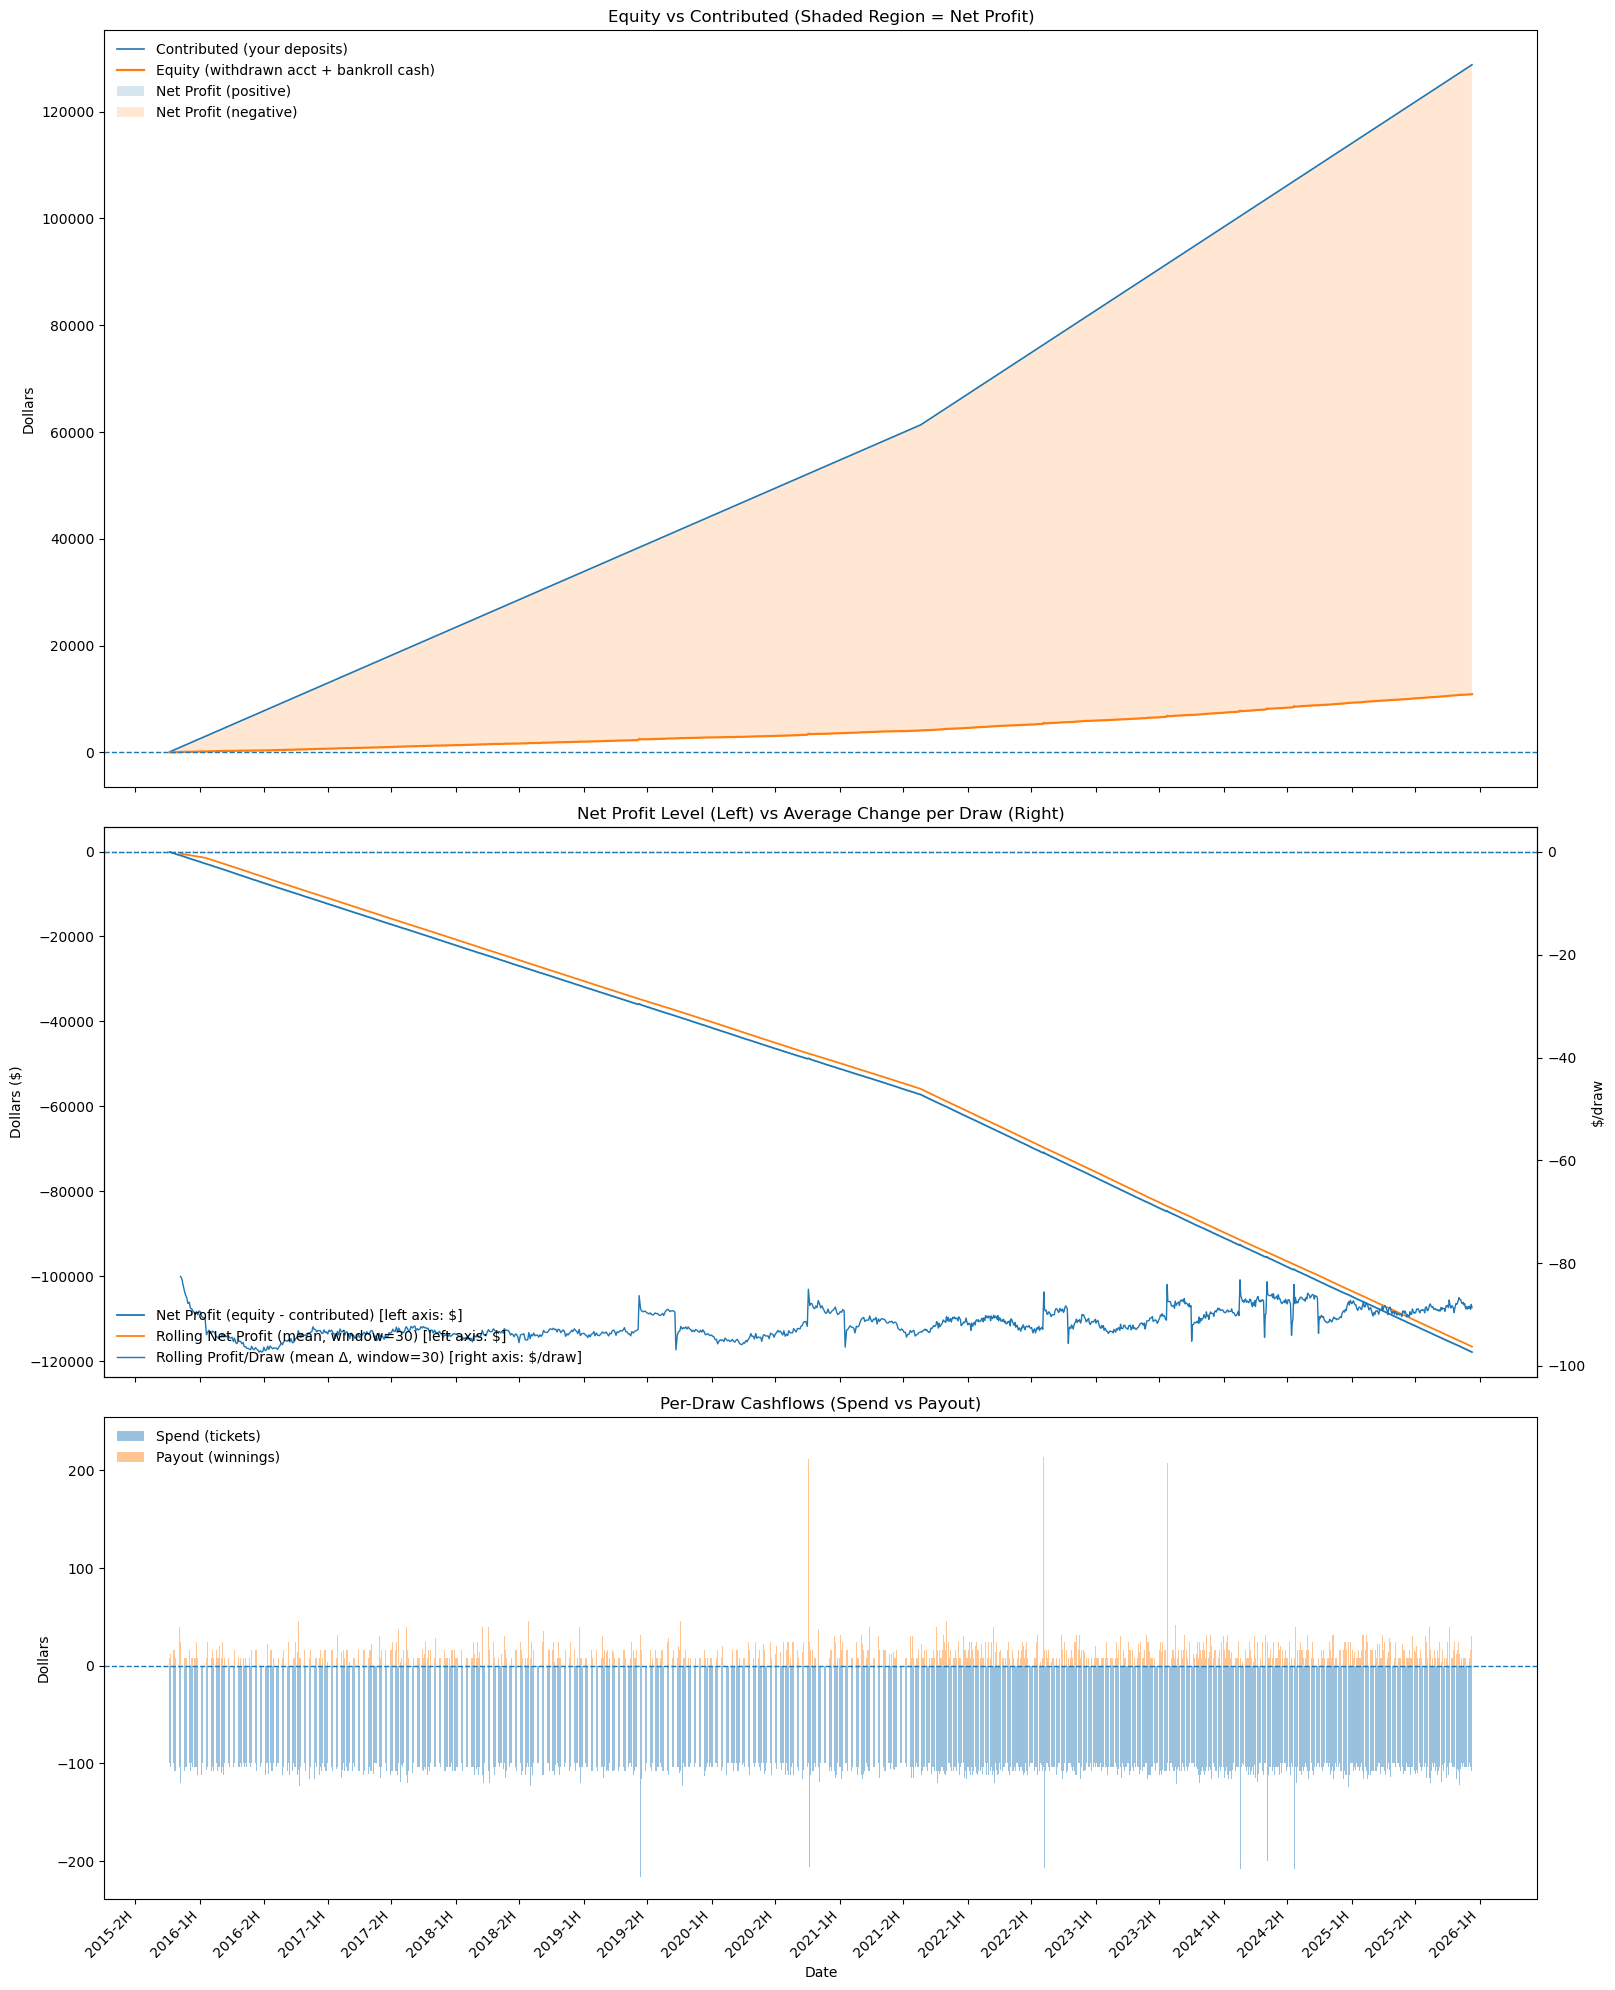

In [10]:
bt.plot_winnings(out)

### 5) Plot a single run with dual-axis “net profit level vs profit/draw” and cashflows

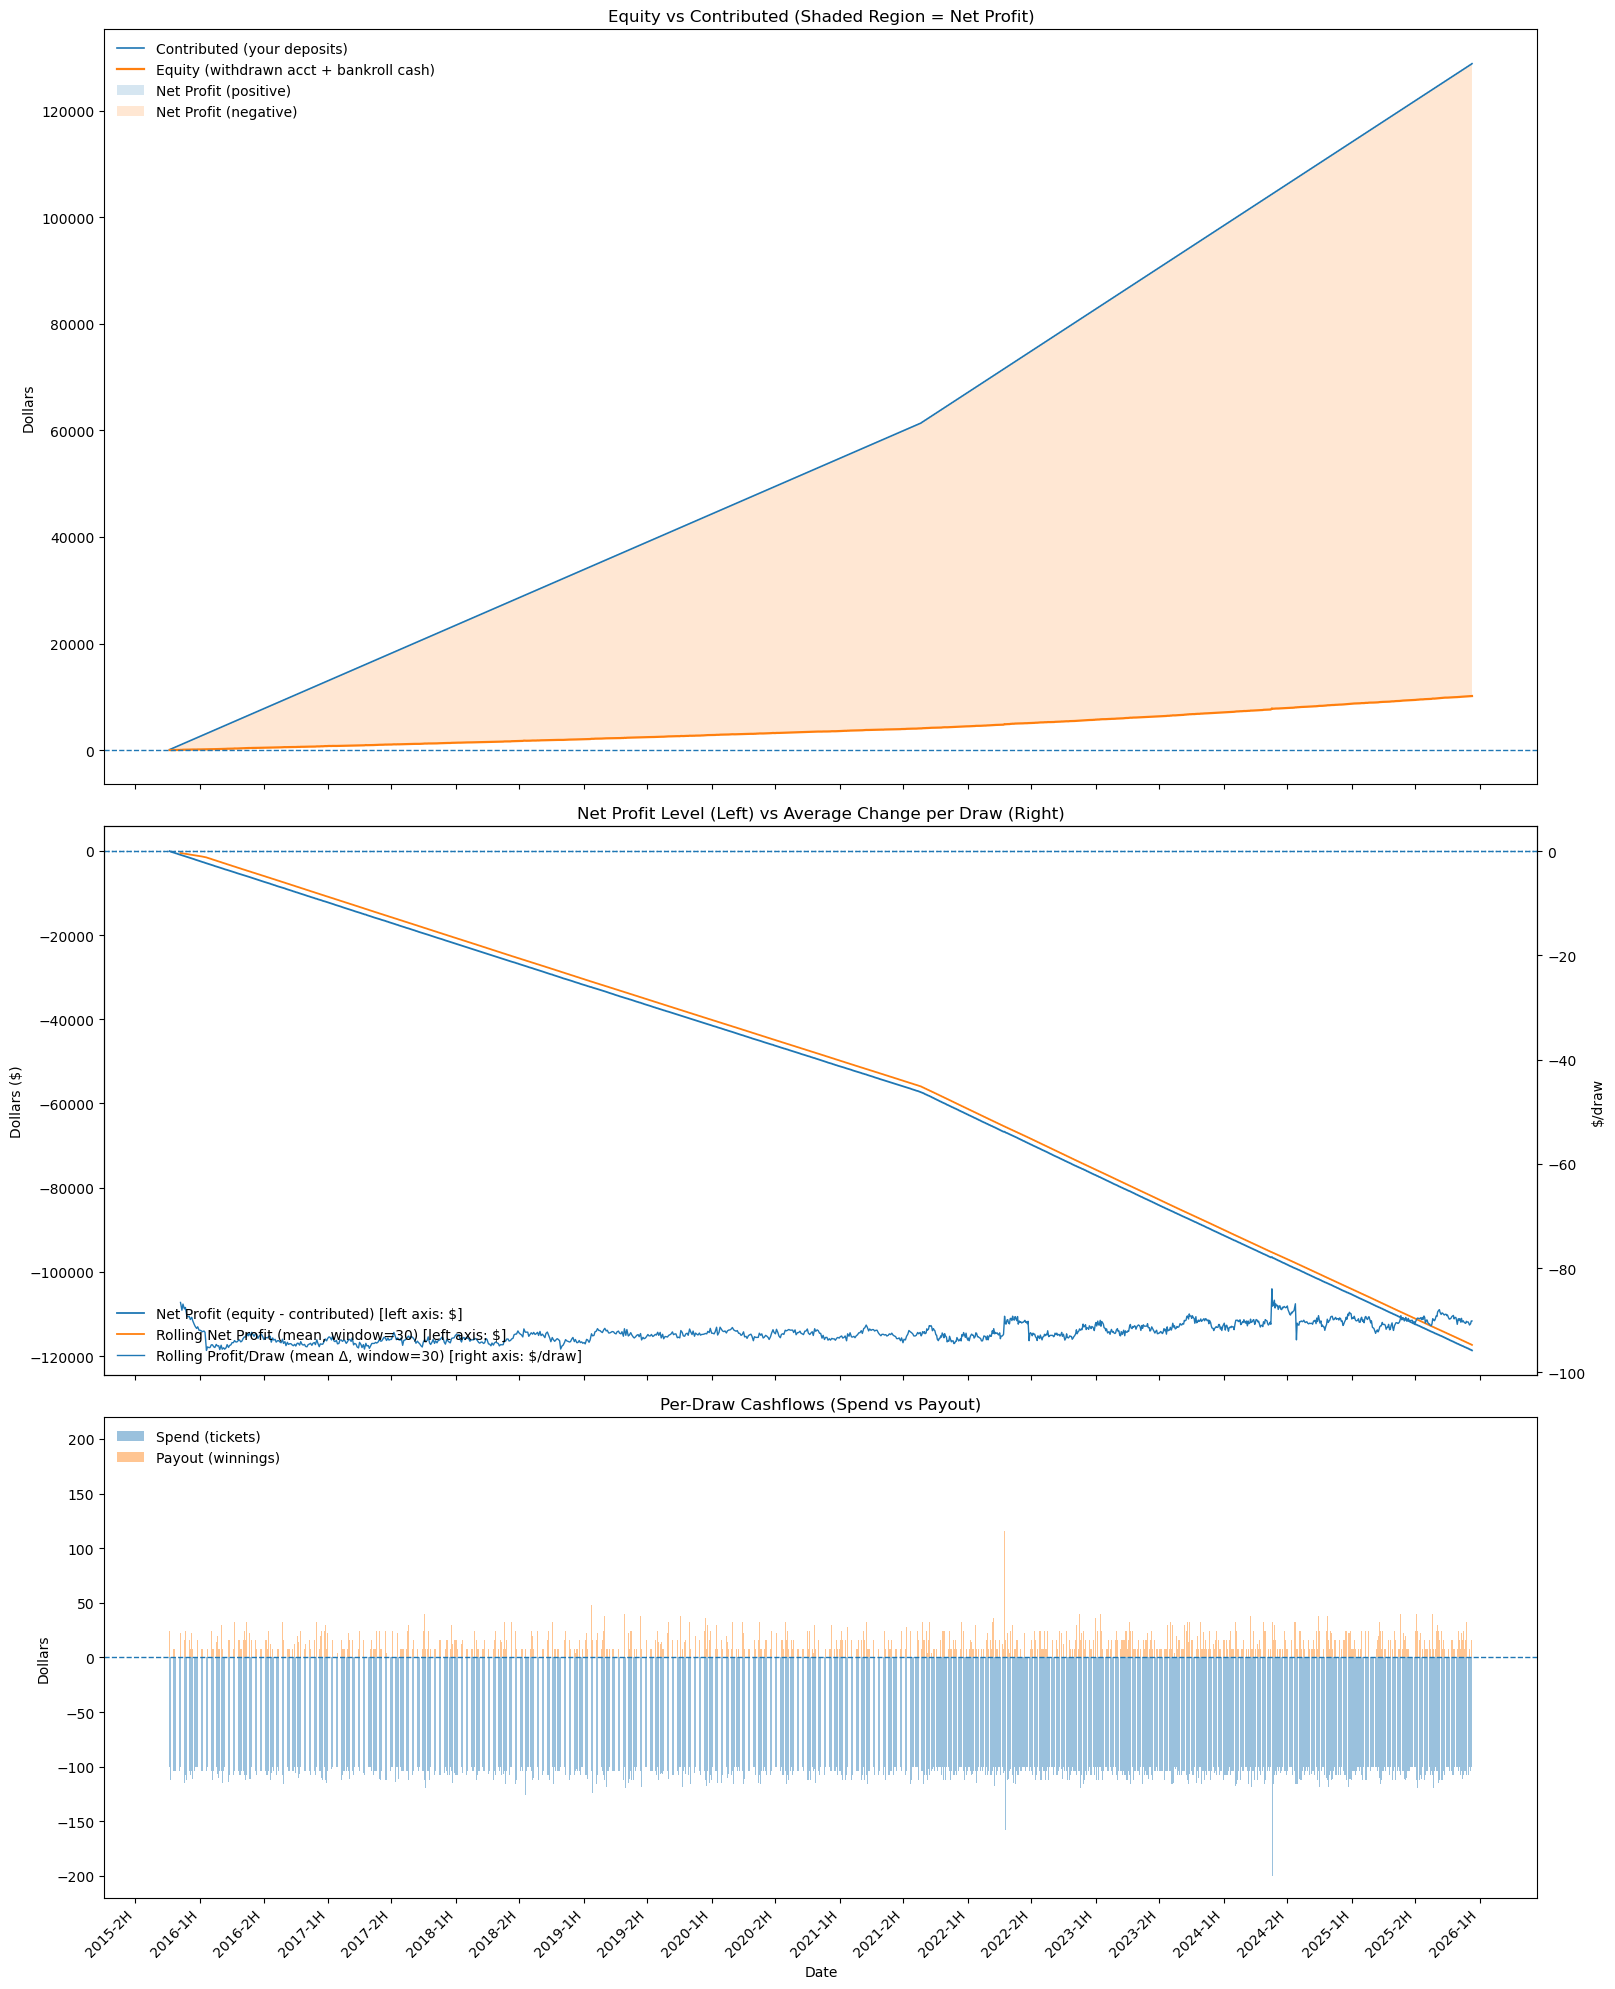

In [11]:
out = bt.run(seed=123)
bt.plot_winnings(out)
# optional:
ticket_df = bt.last_ticket_detail
summary = bt.last_summary

### 6) Temperature-stratified performance (deciles of white temperature)

In [22]:
draw_detail = bt.run(seed=123)  # run() returns draw_detail now :contentReference[oaicite:1]{index=1}
ticket_detail = bt.last_ticket_detail  # populated by run() :contentReference[oaicite:2]{index=2}

summary = bt.summarize_by_white_temperature_deciles(ticket_detail, q=10)
summary

,mean_payout,hit_rate,n
temp_bin,,,
"(35.002, 41.709]",0.315982,0.038813,4380
"(41.709, 48.184]",0.297328,0.036538,4379
"(48.184, 54.652]",0.312857,0.039050,4379
"(54.652, 61.059]",0.326330,0.040420,4379
"(61.059, 67.72]",0.300069,0.036766,4379
"(67.72, 74.284]",0.327472,0.039963,4379
"(74.284, 80.746]",0.377027,0.040649,4379
"(80.746, 87.094]",0.300525,0.037223,4379
"(87.094, 93.525]",0.330669,0.035853,4379


### 7) Performance run: turn off metadata to reduce overhead (store_temperatures=False)

In [23]:
bt_fast = PowerballBacktester(
    draw_csv="V2/powerball.csv",
    jackpot_csv="V2/jackpots.csv",
    generator=gen,
    ticket_budget=500,
    store_temperatures=False,  # leaner generation; no temp columns
    prefer_numba=True,
)

draw_detail = bt_fast.run(seed=123)  # returns draw_detail :contentReference[oaicite:3]{index=3}
ticket_detail = bt_fast.last_ticket_detail  # populated by run() :contentReference[oaicite:4]{index=4}

print(ticket_detail.columns)  # should not include white_temperature/red_temperature

Index(['date', 'cost', 'payout', 'multiplier', 'white_1', 'white_2', 'white_3',
       'white_4', 'white_5', 'red_ball'],
      dtype='object')


### 8) Verify multiplier economics and budget allocation behavior

In [16]:
bt_alloc = PowerballBacktester(
    draw_csv="V2/powerball.csv",
    jackpot_csv="V2/jackpots.csv",
    generator=gen,
    ticket_budget=7,
    use_multiplier=True,
)

# Internal allocation logic: (n_multiplier, n_non_multiplier)
print(bt_alloc._allocate_ticket_counts(7))   # expected pattern like (1, 2)
print(bt_alloc._allocate_ticket_counts(10))  # expected pattern like (2, 2)

(1, 2)
(2, 2)


### 9) Enforced uniqueness across multiplier and non-multiplier pools (per draw)

In [24]:
bt = PowerballBacktester(
    draw_csv="V2/powerball.csv",
    jackpot_csv="V2/jackpots.csv",
    generator=gen,            # must support existing_tickets=...
    ticket_budget=101,
    use_multiplier=True,
)

draw_detail = bt.run(seed=99)          # returns draw_detail :contentReference[oaicite:5]{index=5}
td = bt.last_ticket_detail             # ticket-level rows :contentReference[oaicite:6]{index=6}

dupes = td.duplicated(
    subset=["date", "white_1", "white_2", "white_3", "white_4", "white_5", "red_ball"]
).sum()

print("duplicate tickets within a draw:", dupes)

duplicate tickets within a draw: 0


### 10) Use the generator standalone (CSV-friendly ticket export + uniqueness controls)

In [18]:
from V2.powerball_ticket_generator import TemperatureLotteryGenerator

gen = TemperatureLotteryGenerator(csv_path="V2/powerball.csv")

# Cashier-friendly output (flat columns)
tickets = gen.generate_ticket_batch(
    n=10,
    max_T=50.0,
    include_metadata=False,
    ensure_unique=True,
)

# Export-ready
df = pd.DataFrame(tickets)
df.to_csv("V2/tickets.csv", index=False)

# Enforce uniqueness vs an existing pool (e.g., “don’t repeat last week’s tickets”)
more = gen.generate_ticket_batch(
    n=10,
    max_T=50.0,
    include_metadata=True,
    ensure_unique=True,
    existing_tickets=tickets,
)


In [21]:
df

,white_1,white_2,white_3,white_4,white_5,red_ball
0,11,23,58,61,64,17
1,13,45,47,60,68,18
2,17,26,34,54,67,5
3,2,11,17,56,65,26
4,2,3,14,45,65,17
5,19,28,31,48,51,2
6,27,33,45,51,53,23
7,19,21,38,48,52,25
8,24,27,35,41,52,3
9,17,34,45,51,54,17


In [20]:
pd.DataFrame(more)

,white_balls,red_ball,T_white,T_red,max_T
0,"[9, 13, 23, 29, 33]",15,35.628462,21.121455,50.0
1,"[21, 29, 53, 59, 67]",15,38.864467,39.117002,50.0
2,"[23, 27, 65, 66, 69]",6,43.327269,44.496496,50.0
3,"[6, 9, 32, 36, 38]",9,40.909018,26.129972,50.0
4,"[16, 32, 45, 47, 56]",19,36.849650,47.043939,50.0
5,"[9, 19, 20, 55, 60]",14,38.487351,22.147330,50.0
6,"[10, 11, 25, 59, 66]",2,47.194851,25.364241,50.0
7,"[1, 3, 18, 28, 30]",3,44.630017,31.520961,50.0
8,"[5, 7, 22, 42, 56]",5,42.353658,28.890169,50.0
9,"[19, 26, 35, 42, 46]",8,42.214831,24.300255,50.0
